# Hierarchical Model

Created on 2026-09-17

@author: Ruowen Xiao

## Data Processing

In [ ]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import pandas as pd

In [42]:
# Read Data
data_file = "./data/towelData.csv"
df = pd.read_csv(data_file, sep=";", encoding="latin1")
df.head()

,Source,AuthorName,Experiment,Year,Group,Towel.Reuse,Count
0,Goldstein.2008.Ex1,Goldstein et al.,1,2008,Control,Yes,74
1,Goldstein.2008.Ex1,Goldstein et al.,1,2008,Social Norm,Yes,98
2,Goldstein.2008.Ex1,Goldstein et al.,1,2008,Control,No,137
3,Goldstein.2008.Ex1,Goldstein et al.,1,2008,Social Norm,No,124
4,Goldstein.2008.Ex2,Goldstein et al.,2,2008,Control,Yes,103


In [19]:
# Combine Data
combined_data = (
    df
    .pivot(index=["Source", "Group"], 
           columns="Towel.Reuse", 
           values="Count")
    .reset_index()
)
combined_data["Total"] = combined_data["Yes"] + combined_data["No"]
combined_data["Study"] = combined_data.groupby("Source").ngroup() + 1
combined_data

Towel.Reuse,Source,Group,No,Yes,Total,Study
0,Bohner2014.Ex1,Control,24,123,147,1
1,Bohner2014.Ex1,Social Norm,104,472,576,1
2,Bohner2014.Ex2,Control,2,28,30,2
3,Bohner2014.Ex2,Social Norm,31,101,132,2
4,Goldstein.2008.Ex1,Control,137,74,211,3
5,Goldstein.2008.Ex1,Social Norm,124,98,222,3
6,Goldstein.2008.Ex2,Control,174,103,277,4
7,Goldstein.2008.Ex2,Social Norm,731,587,1318,4
8,Mair2010,Control,4,21,25,5
9,Mair2010,Social Norm,3,21,24,5


In [13]:
# Convert Data Types
combined_data["Group"] = combined_data["Group"].astype("category")
combined_data["Study"] = combined_data["Group"].astype("category")
combined_data.dtypes

Towel.Reuse
Source             str
AuthorName         str
Experiment       int64
Year             int64
Group         category
No               int64
Yes              int64
Total            int64
Study         category
dtype: object

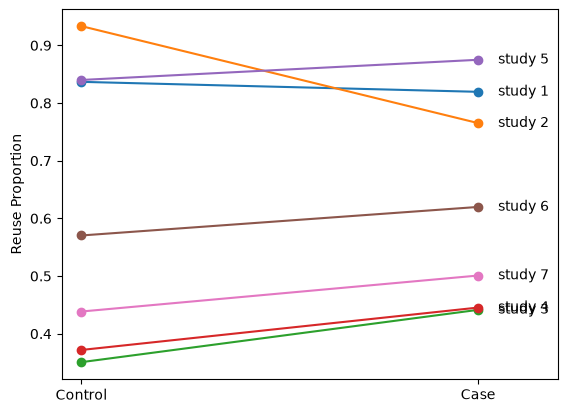

In [35]:
# Plot Reuse Proportion
reuse_prop = combined_data["Yes"] / combined_data["Total"]
fig, ax = plt.subplots()
for i in range(len(reuse_prop) // 2):
    ax.plot([0, 1], [reuse_prop[2*i], reuse_prop[2*i+1]], marker="o")
    ax.text(1.05, reuse_prop[2*i+1], f"study {i+1}", va="center")
ax.set_xlim(-0.05, 1.20)
ax.set_xticks([0, 1], ["Control", "Case"])
ax.set_ylabel("Reuse Proportion")
plt.show()

## Hierarchical Model

Let $Y$ be the reuse count, $Y$ follows a binomial distribution: $$Y \vert_{x_{ij}} \sim \text{Bin} (n_{ij}, p(x_{ij}))$$

Hierarchical Model: $$\text{logit} (p(x_{ij})) = \log (\frac{p(x_{ij})}{1 - p(x_{ij})}) = \beta_0 + u_j + \beta_1 x_{ij}$$

In [ ]:
# Build Model
model_hierarhical = bmb.Model(
    "p(Yes, Total) ~ 1 + Group + (1 | Study)", 
    combined_data, 
    family="binomial"
)
model_hierarhical

       Formula: p(Yes, Total) ~ 1 + Group + (1 | Study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            Group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|Study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))

In [ ]:
# Fit Model
idata_hierarchical = model_hierarhical.fit(
    tune=2000, 
    draws=2000, 
    target_accept = 0.95, 
    random_seed=1234
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, Group, 1|Study_sigma, 1|Study_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 18 seconds.


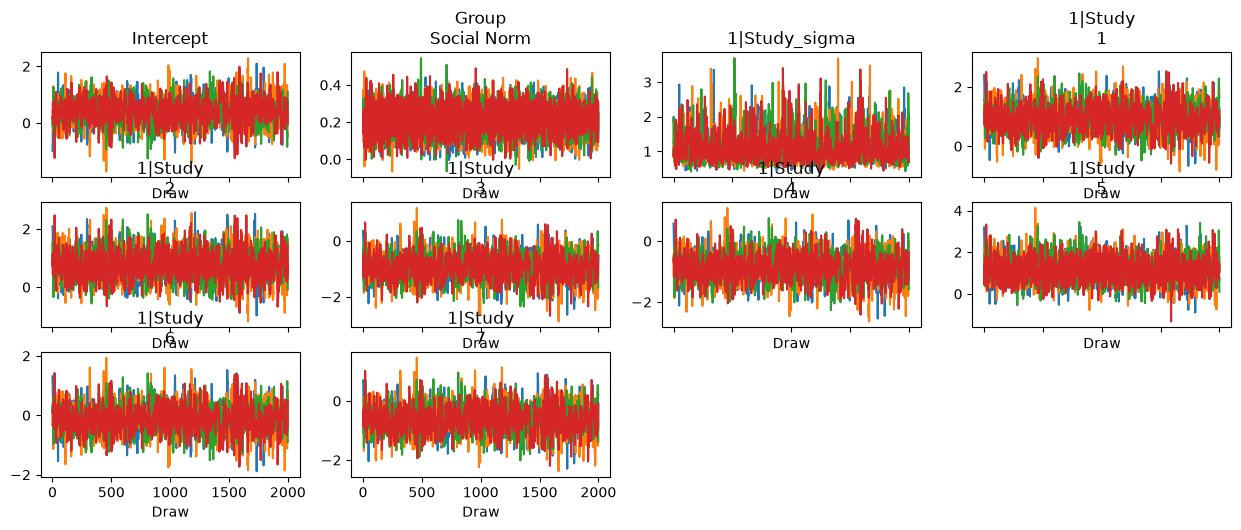

In [51]:
var_names = [
    "Intercept", 
    "Group", 
    "1|Study_sigma", 
    "1|Study"
]
az.plot_trace(
    idata_hierarchical, 
    var_names=var_names, 
)

In [ ]:
az.summary(idata_hierarchical, ci_prob=0.90)

,mean,sd,eti90_lb,eti90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.4,0.42,-0.28,1.1,1752,2065,1.00,0.01,0.0082
Group[Social Norm],0.211,0.077,0.085,0.34,5266,3910,1.00,0.0011,0.001
1|Study_sigma,1.1,0.4,0.63,1.9,1468,2211,1.00,0.01,0.0096
1|Study[1],0.96,0.43,0.26,1.7,1818,2033,1.00,0.0099,0.0078
1|Study[2],0.77,0.45,0.032,1.5,1951,2424,1.00,0.01,0.0079
1|Study[3],-0.92,0.43,-1.6,-0.22,1830,2283,1.00,0.01,0.0082
1|Study[4],-0.85,0.42,-1.5,-0.16,1776,2231,1.00,0.01,0.0081
1|Study[5],1.14,0.55,0.3,2.1,2546,3231,1.00,0.011,0.0082
1|Study[6],-0.12,0.42,-0.82,0.56,1771,2048,1.00,0.01,0.0079
1|Study[7],-0.62,0.42,-1.3,0.077,1795,2333,1.00,0.01,0.0079


## Hypothesis Testing

We derive the slope's posterior probability of the null hypothesis to test if there is a positive association between towel reuse count and descriptive social norms. We set the posterior probablity threshold $P(\beta_1 \leq 0 \vert Y) = 0.05$.

- Null Hypothesis $H_0$: $\beta_1 \leq 0$

- Alternative Hypothesis $H_1$: $\beta_1 > 0$

In [58]:
beta1 = idata_hierarchical.posterior["Group"]
p_value = (beta1 <= 0).mean()
p_value

<xarray.DataArray 'Group' ()> Size: 8B
array(0.002375)

The posterior probablity of the null hypothesis is $0.002375$. The 90% posterior probability interval for $\beta_1$ is $[0.085, 0.34]$, which doesn't cover zero. These results strongly indicate a positive intervention effect of descriptive social norms on towel reuse.